### CUSTOMER CHURN PREDICTION

In [31]:
!pip install numpy==1.26.4

In [32]:
!pip uninstall shap -y

Found existing installation: shap 0.44.1
Uninstalling shap-0.44.1:
  Successfully uninstalled shap-0.44.1


In [33]:
!pip install shap==0.44.1

  Using cached shap-0.44.1-cp312-cp312-macosx_11_0_arm64.whl


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv("/Users/thoshithakolisetty/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.shape

(7043, 21)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [37]:
df.isnull().sum()              #Checking Missing Values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')   #TotalCharges sometimes contains blank values so that must be converted to numeric
df = df.dropna()                           

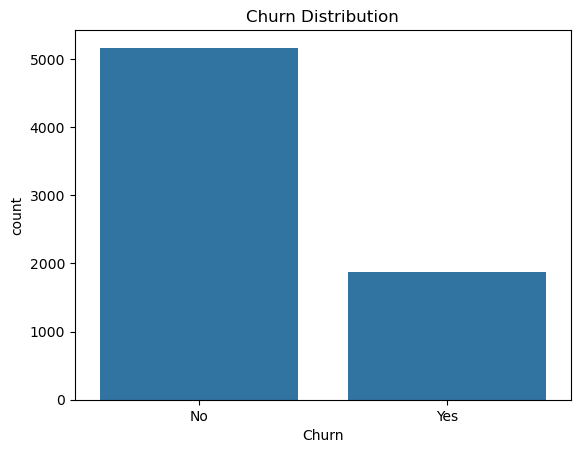

In [39]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [40]:
df = df.drop("customerID", axis=1)          #since not useful for prediction

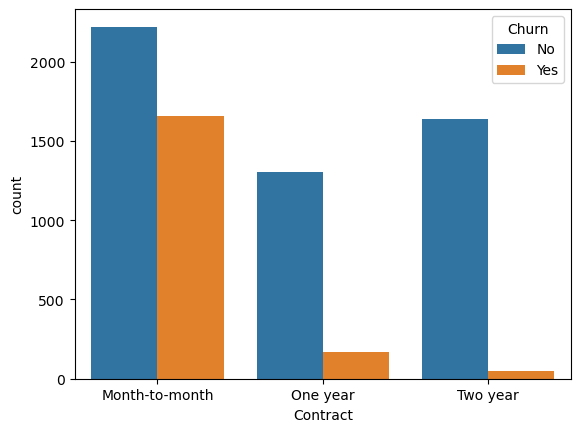

In [41]:
sns.countplot(x='Contract', hue='Churn', data=df)         #contract vs churn
plt.show()

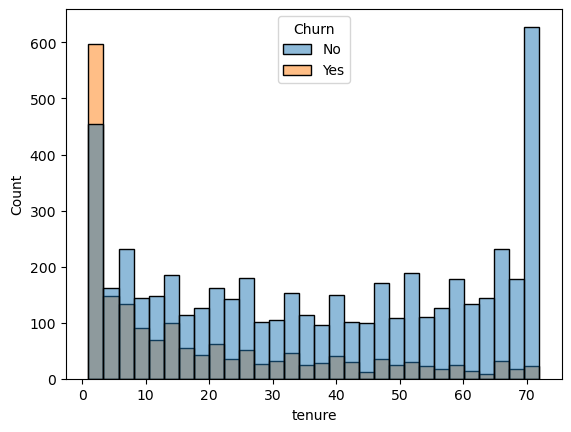

In [42]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)     #Tenure vs Churn
plt.show()

In [43]:
le = LabelEncoder()                              #converting categorical data
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [44]:
X = df.drop("Churn", axis=1)                   #Feature Selection (Seperating input and target)
y = df["Churn"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)     #Train-Test Split

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [47]:
log_model = LogisticRegression(max_iter=1000)      #Training ML Model(Logistic Regression)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.7867803837953091


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
dt_model = DecisionTreeClassifier()     #Training ML Model(Decision Tree)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7228144989339019


In [49]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)      #Training ML Model(Random Forest)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7867803837953091


In [50]:
results = pd.DataFrame({                                                      #Comparing Models
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.786780
1        Decision Tree  0.722814
2        Random Forest  0.786780


In [51]:
df['Churn_Probability'] = rf_model.predict_proba(X)[:,1]

In [52]:
df['Predicted_Churn'] = rf_model.predict(X)

In [53]:
df['Predicted_Churn'] = df['Predicted_Churn'].map({1:'Yes', 0:'No'})

In [54]:
from sklearn.metrics import confusion_matrix     #confusion matrix for best model
confusion_matrix(y_test, rf_pred)

array([[928, 105],
       [195, 179]])

In [55]:
from sklearn.ensemble import RandomForestClassifier                     #To know important features affecting using random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importance = rf.feature_importances_
features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
print(features.head(10))

            Feature  Importance
18     TotalCharges    0.185946
17   MonthlyCharges    0.178794
4            tenure    0.153104
14         Contract    0.080983
16    PaymentMethod    0.051886
8    OnlineSecurity    0.048463
11      TechSupport    0.047414
0            gender    0.026755
7   InternetService    0.026742
9      OnlineBackup    0.025844


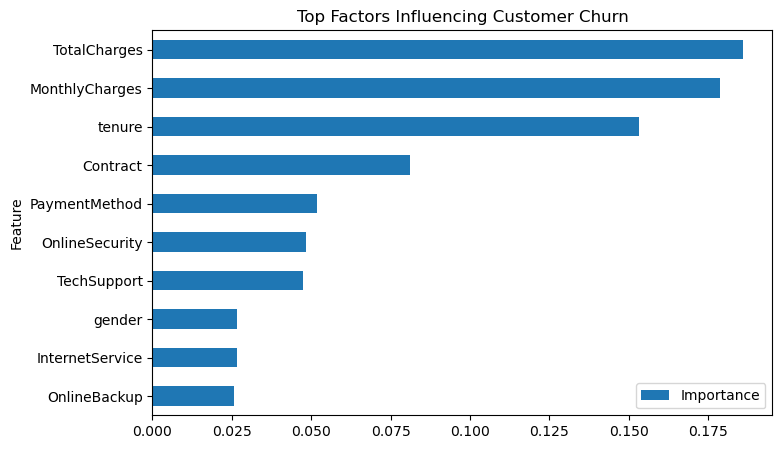

In [56]:
import matplotlib.pyplot as plt
features.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)
plt.title("Top Factors Influencing Customer Churn")
plt.gca().invert_yaxis()
plt.show()

In [57]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
df['Cluster'] = kmeans.fit_predict(X)
df['Cluster'].value_counts()

Cluster
0    3207
2    1690
1    1184
3     951
Name: count, dtype: int64

In [58]:
sample_customer = X_test.iloc[0].values.reshape(1,-1)               #Example churn prediction( 1= customer will churn; 0=customet will stay)
prediction = log_model.predict(sample_customer)
print(prediction)

[0]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [59]:
sample_customer = X_test.iloc[10].values.reshape(1,-1)               #Example churn prediction( 1= customer will churn; 0=customet will stay)
prediction = log_model.predict(sample_customer)
print(prediction)

[1]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [37]:
df.to_csv("churn_with_predictions.csv", index=False)